In [138]:
# Task 3 - Linear Regression
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [139]:
# Load the House Price Prediction dataset

df = pd.read_csv('/content/Housing.csv')

# Display the first 5 rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [140]:
# Check the dataset structure

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Dataset shape: (545, 13)

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingst

In [141]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate Rows:
0


In [142]:
# Summary statistics for numerical columns

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [143]:
# Make a copy so the original dataset remains unchanged
df_processed = df.copy()

# Convert yes/no columns into 1/0
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    df_processed[column] = df_processed[column].map({
        'yes': 1,
        'no': 0
    })

# One-hot encode furnishing status
df_processed = pd.get_dummies(
    df_processed,
    columns=['furnishingstatus'],
    drop_first=True
)

# Display the processed dataset
df_processed.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [144]:
# Check the processed dataset

print("Processed dataset shape:", df_processed.shape)

print("\nProcessed columns:")
print(df_processed.columns.tolist())

print("\nData types:")
print(df_processed.dtypes)

Processed dataset shape: (545, 14)

Processed columns:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Data types:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [145]:
# Separate features and target

X = df_processed.drop('price', axis=1)
y = df_processed['price']

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("price")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X):
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

Target (y):
price

X shape: (545, 13)
y shape: (545,)


In [146]:
# Check data types of features

print(X.dtypes)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object

Non-numeric columns:
['furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [147]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (436, 13)
y_train: (436,)

Testing set:
X_test: (109, 13)
y_test: (109,)


In [148]:
# Prepare data for Simple Linear Regression

X_simple = df_processed[['area']]
y_simple = df_processed['price']

# Split the simple regression data
X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple,
    y_simple,
    test_size=0.20,
    random_state=42
)

print("Simple Linear Regression data prepared.")
print("Training samples:", len(X_simple_train))
print("Testing samples:", len(X_simple_test))

Simple Linear Regression data prepared.
Training samples: 436
Testing samples: 109


In [149]:
# Train the Simple Linear Regression model

simple_model = LinearRegression()

simple_model.fit(
    X_simple_train,
    y_simple_train
)

print("Simple Linear Regression model trained successfully!")

Simple Linear Regression model trained successfully!


In [150]:
# Make predictions

y_simple_pred = simple_model.predict(X_simple_test)

print("First 10 predictions:")
print(y_simple_pred[:10])

First 10 predictions:
[5024060.33139816 5279498.23656143 4232202.82539203 4640903.47365326
 4198144.43803692 5373158.80178796 6139472.51727777 4636646.17523387
 3891618.951841   3661724.83719406]


In [151]:
# Evaluate the Simple Linear Regression model

simple_mae = mean_absolute_error(y_simple_test, y_simple_pred)
simple_mse = mean_squared_error(y_simple_test, y_simple_pred)
simple_r2 = r2_score(y_simple_test, y_simple_pred)

print("Simple Linear Regression Results")
print("---------------------------------")
print(f"MAE : {simple_mae:.2f}")
print(f"MSE : {simple_mse:.2f}")
print(f"R²  : {simple_r2:.4f}")

Simple Linear Regression Results
---------------------------------
MAE : 1474748.13
MSE : 3675286604768.19
R²  : 0.2729


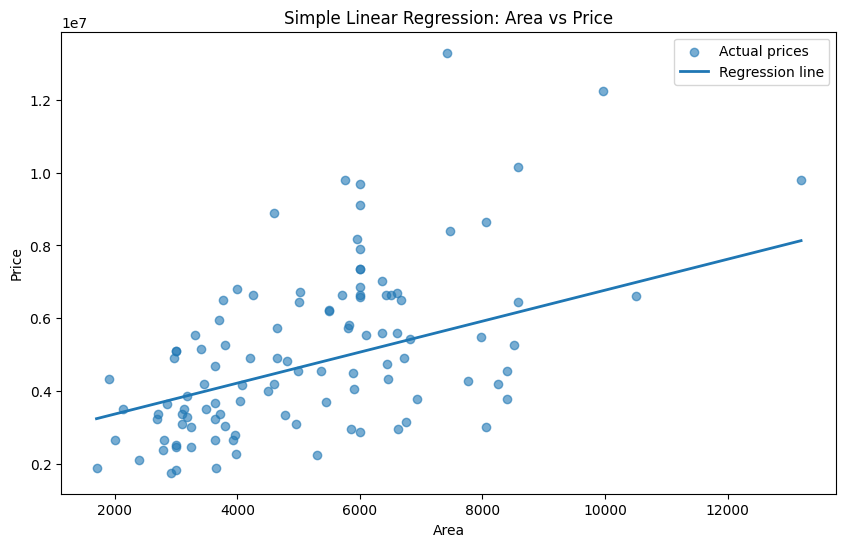

In [152]:
# Plot the Simple Linear Regression line

plt.figure(figsize=(10, 6))

plt.scatter(
    X_simple_test['area'],
    y_simple_test,
    alpha=0.6,
    label='Actual prices'
)

# Sort values so the regression line is displayed correctly
sorted_indices = X_simple_test['area'].argsort()

plt.plot(
    X_simple_test['area'].iloc[sorted_indices],
    y_simple_pred[sorted_indices],
    linewidth=2,
    label='Regression line'
)

plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Simple Linear Regression: Area vs Price')
plt.legend()

plt.show()

In [153]:
# Display the Simple Linear Regression coefficients

print("Intercept:", simple_model.intercept_)
print("Area coefficient:", simple_model.coef_[0])

Intercept: 2512254.2639593435
Area coefficient: 425.72984193878284


In [154]:
# Prepare data for Multiple Linear Regression

X_multiple = df_processed.drop('price', axis=1)
y_multiple = df_processed['price']

# Split into training and testing sets
X_multiple_train, X_multiple_test, y_multiple_train, y_multiple_test = train_test_split(
    X_multiple,
    y_multiple,
    test_size=0.20,
    random_state=42
)

print("Multiple Linear Regression data prepared.")
print("Training samples:", len(X_multiple_train))
print("Testing samples:", len(X_multiple_test))
print("Number of features:", X_multiple.shape[1])

Multiple Linear Regression data prepared.
Training samples: 436
Testing samples: 109
Number of features: 13


In [155]:
# Train the Multiple Linear Regression model

multiple_model = LinearRegression()

multiple_model.fit(
    X_multiple_train,
    y_multiple_train
)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [156]:
# Make predictions

y_multiple_pred = multiple_model.predict(X_multiple_test)

print("First 10 predictions:")
print(y_multiple_pred[:10])

First 10 predictions:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782]


In [157]:
# Evaluate the Multiple Linear Regression model

multiple_mae = mean_absolute_error(
    y_multiple_test,
    y_multiple_pred
)

multiple_mse = mean_squared_error(
    y_multiple_test,
    y_multiple_pred
)

multiple_r2 = r2_score(
    y_multiple_test,
    y_multiple_pred
)

print("Multiple Linear Regression Results")
print("----------------------------------")
print(f"MAE : {multiple_mae:.2f}")
print(f"MSE : {multiple_mse:.2f}")
print(f"R²  : {multiple_r2:.4f}")

Multiple Linear Regression Results
----------------------------------
MAE : 970043.40
MSE : 1754318687330.66
R²  : 0.6529


In [158]:
# Compare Simple and Multiple Linear Regression

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression',
        'Multiple Linear Regression'
    ],
    'MAE': [
        simple_mae,
        multiple_mae
    ],
    'MSE': [
        simple_mse,
        multiple_mse
    ],
    'R²': [
        simple_r2,
        multiple_r2
    ]
})

comparison

,Model,MAE,MSE,R²
0,Simple Linear Regression,1.474748e+06,3.675287e+12,0.272879
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924


In [159]:
# Display Multiple Linear Regression coefficients

coefficients = pd.DataFrame({
    'Feature': X_multiple.columns,
    'Coefficient': multiple_model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [160]:
# Display the intercept

print("Intercept:", multiple_model.intercept_)

Intercept: 260032.35760741122


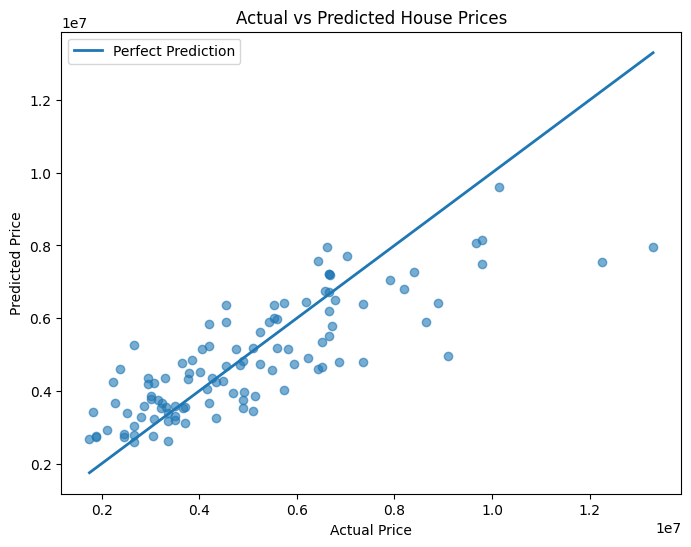

In [161]:
# Actual vs Predicted House Prices

plt.figure(figsize=(8, 6))

plt.scatter(
    y_multiple_test,
    y_multiple_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_multiple_test.min(), y_multiple_pred.min())
max_value = max(y_multiple_test.max(), y_multiple_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2,
    label='Perfect Prediction'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()

plt.show()